# DengueRadar

Predicting MOH area level dengue risk tiers (Low / Watch / Warning / Alert) 1 week ahead, for Sri Lanka.




## Section 0 — Setup & Config

In [1]:


import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = "dengueradar_training_table.csv"
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

TIER_ORDER = ["Low", "Watch", "Warning", "Alert"]
TIER_TO_INT = {t: i for i, t in enumerate(TIER_ORDER)}
INT_TO_TIER = {i: t for t, i in TIER_TO_INT.items()}

print("Config OK. Random seed:", RANDOM_SEED)

Config OK. Random seed: 42


In [2]:
def tier_mae(y_true_int, y_pred_int):
    """Mean absolute distance between predicted and true tier (0=Low..3=Alert).
    A prediction of 'Watch' when truth is 'Alert' is a worse miss than 'Warning'
    vs 'Alert' - this metric captures that, unlike plain accuracy."""
    return np.mean(np.abs(np.asarray(y_true_int) - np.asarray(y_pred_int)))

from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    classification_report, confusion_matrix,
)

## Section 1 — Data Loading

In [3]:
df = pd.read_csv(DATA_PATH)
df["week_start"] = pd.to_datetime(df["week_start"])
df = df.sort_values(["moh_name", "week_start"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["week_start"].min().date(), "->", df["week_start"].max().date())
print("MOH areas:", df["moh_name"].nunique(), " | Districts:", df["district"].nunique())
df.info(memory_usage="deep")

Shape: (17220, 28)
Date range: 2013-12-28 -> 2026-05-11
MOH areas: 27  | Districts: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17220 entries, 0 to 17219
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   moh_code            17220 non-null  int64         
 1   moh_name            17220 non-null  object        
 2   ds_name             17220 non-null  object        
 3   ds_id               17220 non-null  object        
 4   district            17220 non-null  object        
 5   week_start          17220 non-null  datetime64[ns]
 6   iso_year            17220 non-null  int64         
 7   iso_week            17220 non-null  int64         
 8   cases               17220 non-null  int64         
 9   cases_lag1          17193 non-null  float64       
 10  cases_lag2          17166 non-null  float64       
 11  incidence_per_100k  17220 non-null  float64       
 12  risk_tier       

In [4]:
df.head()

,moh_code,moh_name,ds_name,ds_id,district,week_start,iso_year,iso_week,cases,cases_lag1,...,rain_2w,rain_4w,temp_avg_4w,humidity_4w,population,pop_density,birth_rate,area_km2,centroid_lat,centroid_lon
0,10030010,Agalawatta,Agalawatta,LKA.10.1_1,Kalutara,2013-12-28,2013,52,2,NaN,...,2.14,2.14,25.603333,81.520000,37284.0,409.708557,15.8,91.001272,6.514886,80.174688
1,10030010,Agalawatta,Agalawatta,LKA.10.1_1,Kalutara,2014-01-04,2014,1,2,2.0,...,30.41,30.41,25.654524,82.430714,37284.0,409.708557,15.8,91.001272,6.514886,80.174688
2,10030010,Agalawatta,Agalawatta,LKA.10.1_1,Kalutara,2014-01-11,2014,2,1,2.0,...,63.31,65.45,25.754921,82.749048,37284.0,409.708557,15.8,91.001272,6.514886,80.174688
3,10030010,Agalawatta,Agalawatta,LKA.10.1_1,Kalutara,2014-01-18,2014,3,2,1.0,...,35.30,65.71,25.825476,81.455000,37284.0,409.708557,15.8,91.001272,6.514886,80.174688
4,10030010,Agalawatta,Agalawatta,LKA.10.1_1,Kalutara,2014-01-25,2014,4,1,2.0,...,19.56,82.87,25.865357,80.803929,37284.0,409.708557,15.8,91.001272,6.514886,80.174688


## Section 2 — Exploratory Data Analysis

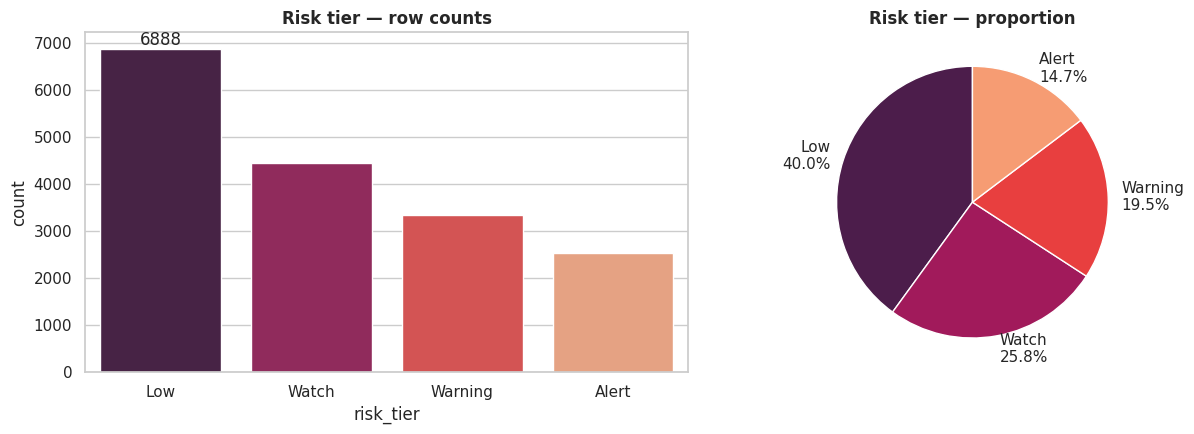

Class imbalance ratio (Low:Alert): 2.7 : 1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = TIER_ORDER
counts = df["risk_tier"].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="rocket", legend=False, ax=axes[0])
axes[0].set_title("Risk tier — row counts")
axes[0].set_ylabel("count")
axes[0].bar_label(axes[0].containers[0])

pct = counts / counts.sum() * 100
axes[1].pie(pct, labels=[f"{t}\n{p:.1f}%" for t, p in zip(order, pct)],
            colors=sns.color_palette("rocket", 4), startangle=90)
axes[1].set_title("Risk tier — proportion")
plt.tight_layout(); plt.show()
print("Class imbalance ratio (Low:Alert):", round(counts['Low'] / counts['Alert'], 1), ": 1")

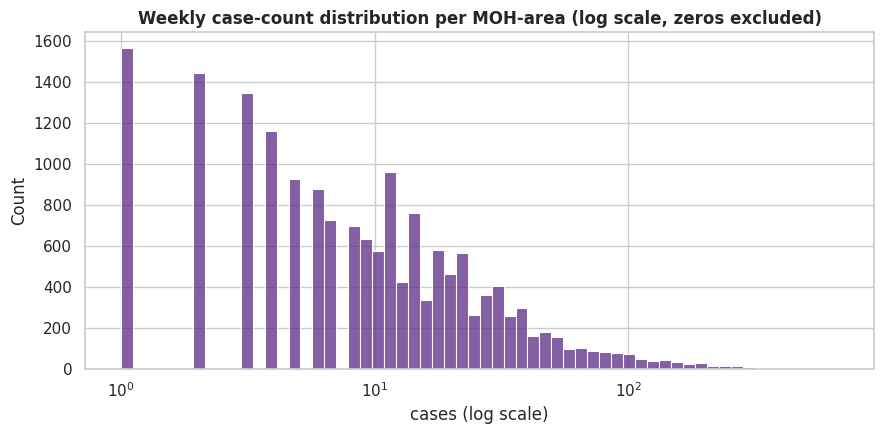

Zero-case weeks: 0.021 of all rows


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df.loc[df["cases"] > 0, "cases"], bins=60, log_scale=True, color="#5b2a86", ax=ax)
ax.set_title("Weekly case-count distribution per MOH-area (log scale, zeros excluded)")
ax.set_xlabel("cases (log scale)")
plt.tight_layout(); plt.show()
print("Zero-case weeks:", (df['cases'] == 0).mean().round(3), "of all rows")

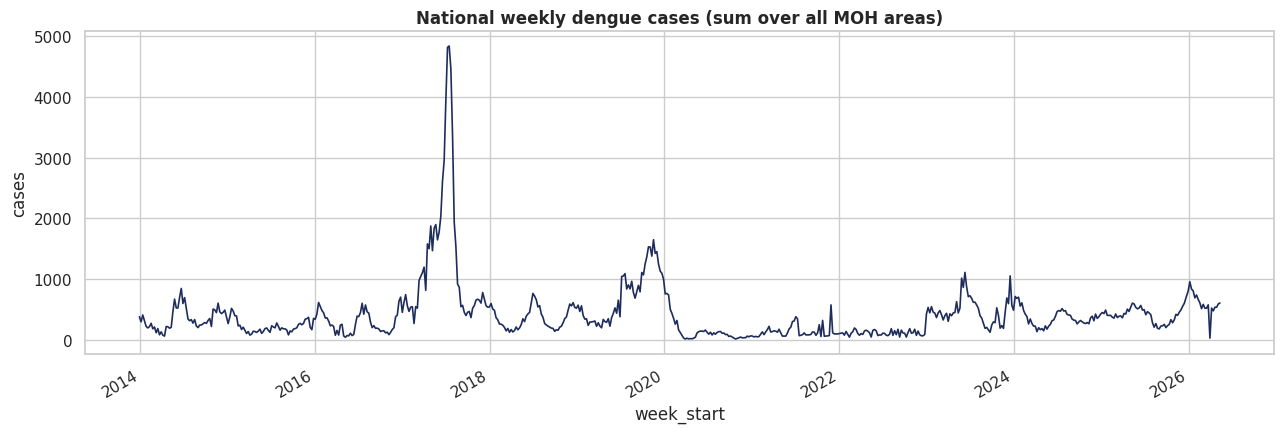

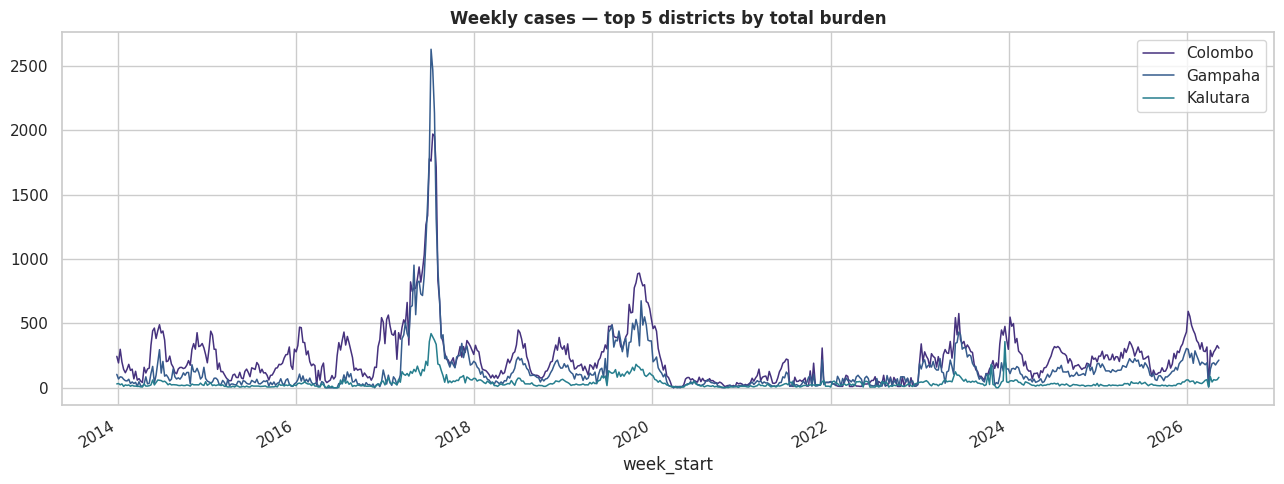

In [7]:
national = df.groupby("week_start")["cases"].sum()
fig, ax = plt.subplots(figsize=(13, 4.5))
national.plot(ax=ax, color="#1f2d5c", lw=1.2)
ax.set_title("National weekly dengue cases (sum over all MOH areas)")
ax.set_ylabel("cases")
plt.tight_layout(); plt.show()

top5_districts = df.groupby("district")["cases"].sum().nlargest(5).index
fig, ax = plt.subplots(figsize=(13, 5))
for d in top5_districts:
    sub = df[df["district"] == d].groupby("week_start")["cases"].sum()
    sub.plot(ax=ax, label=d, lw=1.1)
ax.set_title("Weekly cases — top 5 districts by total burden")
ax.legend(); plt.tight_layout(); plt.show()

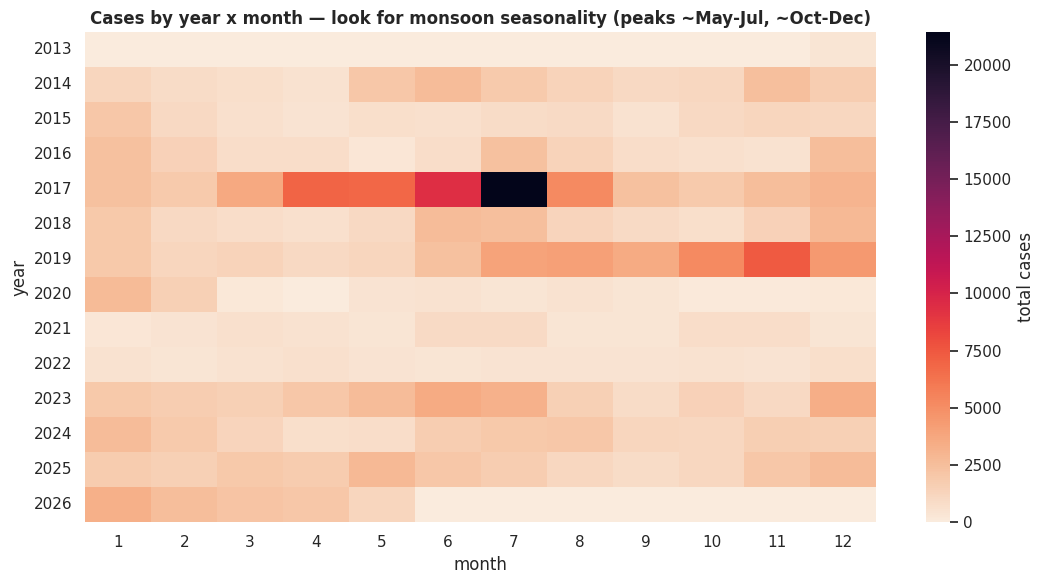

In [8]:
pivot = df.groupby([df["week_start"].dt.year, df["week_start"].dt.month])["cases"].sum().unstack(fill_value=0)
pivot.index.name, pivot.columns.name = "year", "month"
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, cmap="rocket_r", annot=False, ax=ax, cbar_kws={"label": "total cases"})
ax.set_title("Cases by year x month — look for monsoon seasonality (peaks ~May-Jul, ~Oct-Dec)")
plt.tight_layout(); plt.show()

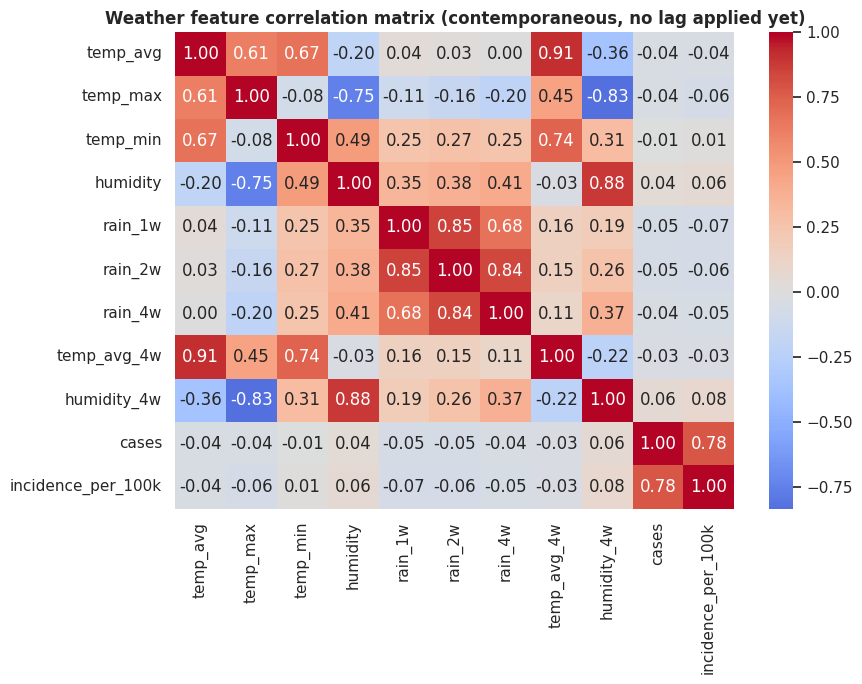

Note: contemporaneous rain correlates weakly with cases by design - the mosquito
life-cycle + incubation delay means rain 2-4 weeks ago matters more (see Section 4 lags).


In [9]:
weather_cols = ["temp_avg", "temp_max", "temp_min", "humidity", "rain_1w", "rain_2w", "rain_4w",
                 "temp_avg_4w", "humidity_4w"]
corr = df[weather_cols + ["cases", "incidence_per_100k"]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Weather feature correlation matrix (contemporaneous, no lag applied yet)")
plt.tight_layout(); plt.show()
print("Note: contemporaneous rain correlates weakly with cases by design - the mosquito")
print("life-cycle + incubation delay means rain 2-4 weeks ago matters more (see Section 4 lags).")

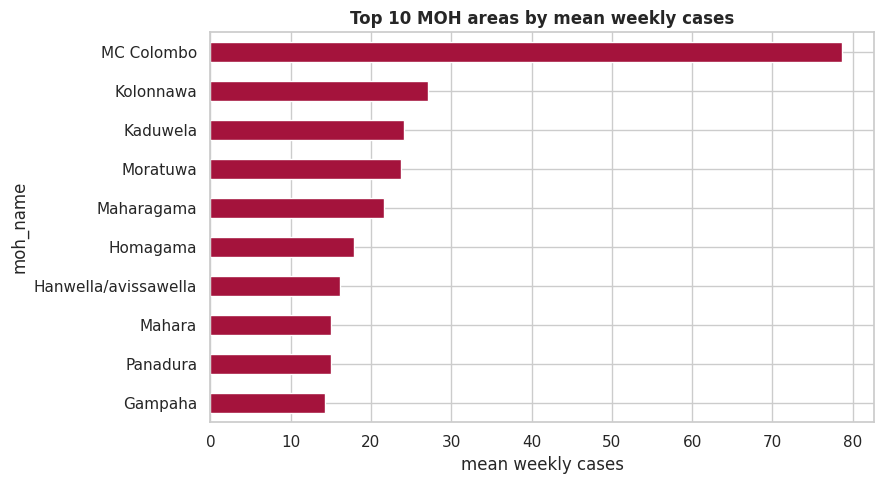

In [10]:
top10 = df.groupby("moh_name")["cases"].mean().nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
top10.plot(kind="barh", color="#a4133c", ax=ax)
ax.set_title("Top 10 MOH areas by mean weekly cases")
ax.set_xlabel("mean weekly cases")
plt.tight_layout(); plt.show()

In [11]:

district_summary = (
    df.groupby("district")
    .agg(mean_weekly_cases=("cases", "mean"),
         total_cases=("cases", "sum"),
         mean_incidence_per_100k=("incidence_per_100k", "mean"),
         n_moh_areas=("moh_name", "nunique"))
    .sort_values("total_cases", ascending=False)
)
display(district_summary.style.background_gradient(cmap="rocket_r", subset=["total_cases"]))

,mean_weekly_cases,total_cases,mean_incidence_per_100k,n_moh_areas
district,,,,
Colombo,25.654971,149158,13.871866,9
Gampaha,11.661894,90403,7.100104,12
Kalutara,6.882868,25150,6.157676,6


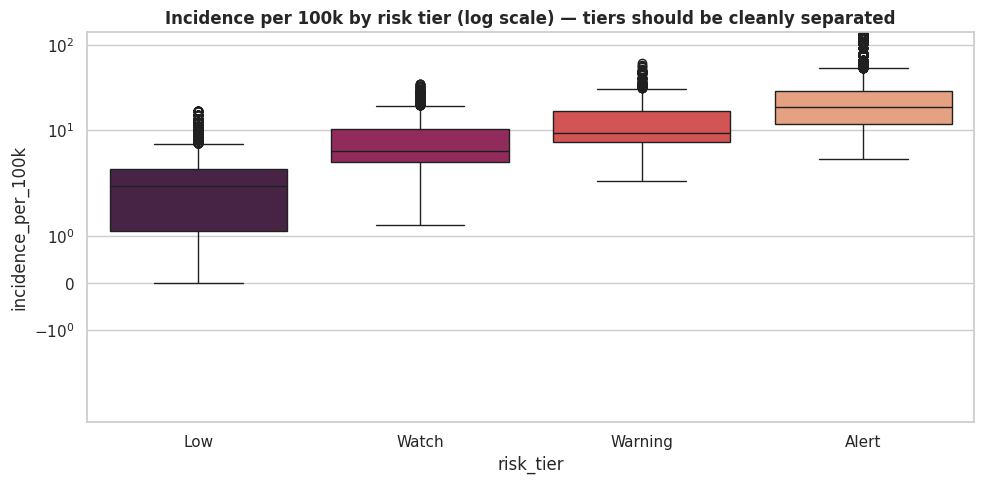

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="risk_tier", y="incidence_per_100k", order=TIER_ORDER,
            hue="risk_tier", palette="rocket", legend=False, ax=ax)
ax.set_yscale("symlog")
ax.set_title("Incidence per 100k by risk tier (log scale) — tiers should be cleanly separated")
plt.tight_layout(); plt.show()

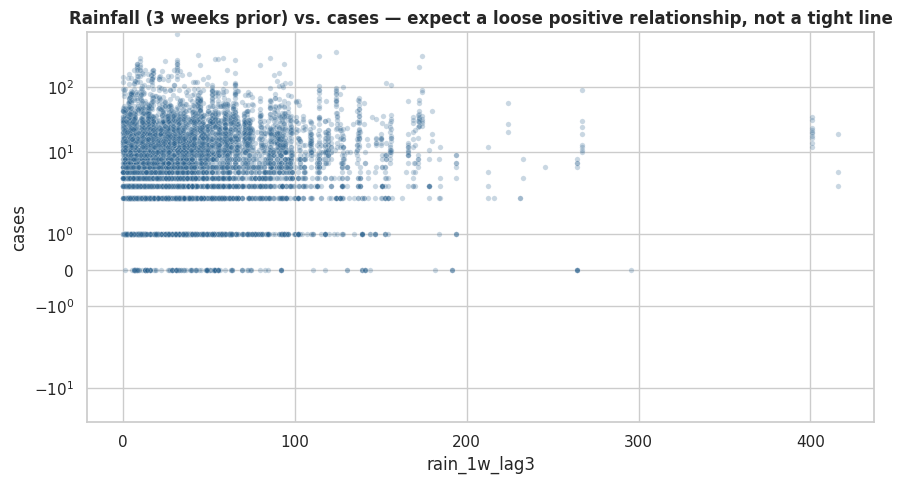

In [14]:
tmp = df.copy()
tmp["rain_1w_lag3"] = tmp.groupby("moh_name")["rain_1w"].shift(3)
fig, ax = plt.subplots(figsize=(9, 5))
sample = tmp.sample(min(8000, len(tmp)), random_state=RANDOM_SEED)
sns.scatterplot(data=sample, x="rain_1w_lag3", y="cases", alpha=0.25, s=15, ax=ax, color="#2a628f")
ax.set_yscale("symlog")
ax.set_title("Rainfall (3 weeks prior) vs. cases — expect a loose positive relationship, not a tight line")
plt.tight_layout(); plt.show()

In [15]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
dupes = df.duplicated(subset=["moh_name", "week_start"]).sum()
print(f"Duplicate (moh_name, week_start) rows: {dupes}")
print(f"Fully duplicate rows: {df.duplicated().sum()}")

Missing values per column:
cases_lag1      27
cases_lag2      54
humidity         1
rain_1w          1
rain_2w          1
rain_4w          1
temp_avg_4w      1
humidity_4w      1
population       1
pop_density      1
birth_rate       1
area_km2         1
centroid_lat     1
centroid_lon     1
dtype: int64

Duplicate (moh_name, week_start) rows: 0
Fully duplicate rows: 0


## Section 3 — Data Quality

In [16]:

assert pd.api.types.is_datetime64_any_dtype(df["week_start"]), "week_start must be datetime"
print("week_start dtype:", df["week_start"].dtype)

print("NaNs before impute:", df[["cases_lag1", "cases_lag2"]].isna().sum().to_dict())
df["cases_lag1"] = df.groupby("moh_name")["cases_lag1"].transform(lambda s: s.bfill())
df["cases_lag2"] = df.groupby("moh_name")["cases_lag2"].transform(lambda s: s.bfill())
print("NaNs after impute:", df[["cases_lag1", "cases_lag2"]].isna().sum().to_dict())

week_start dtype: datetime64[ns]
NaNs before impute: {'cases_lag1': 27, 'cases_lag2': 54}
NaNs after impute: {'cases_lag1': 0, 'cases_lag2': 0}


In [17]:
q999 = df["cases"].quantile(0.999)
extreme = df[df["cases"] > q999]
print(f"99.9th percentile cases: {q999:.0f} | rows above it: {len(extreme)}")
print(extreme[["moh_name", "week_start", "cases"]].sort_values("cases", ascending=False).head(10))

coverage = df.groupby("moh_name").size()
print(f"\nWeeks per MOH area — min {coverage.min()}, max {coverage.max()}, "
      f"{(coverage.nunique())} distinct coverage count(s) across {len(coverage)} MOH areas")
if coverage.nunique() > 1:
    short = coverage[coverage < coverage.max()]
    print("MOH areas with fewer weeks than the rest (check for a mid-series gap):")
    print(short)

99.9th percentile cases: 280 | rows above it: 18
         moh_name week_start  cases
11167  MC Colombo 2017-07-15    672
11168  MC Colombo 2017-07-22    667
11165  MC Colombo 2017-07-01    606
11166  MC Colombo 2017-07-08    601
11169  MC Colombo 2017-07-29    584
11164  MC Colombo 2017-06-24    456
11163  MC Colombo 2017-06-17    432
11162  MC Colombo 2017-06-10    352
11159  MC Colombo 2017-05-20    320
11161  MC Colombo 2017-06-03    312

Weeks per MOH area — min 424, max 646, 2 distinct coverage count(s) across 27 MOH areas
MOH areas with fewer weeks than the rest (check for a mid-series gap):
moh_name
Madurawala    424
dtype: int64


## Section 4 — Feature Engineering

In [18]:
g = df.groupby("moh_name")["cases"]
df["cases_lag3"] = g.shift(3)
df["cases_lag4"] = g.shift(4)
df["cases_lag8"] = g.shift(8)
df["cases_lag12"] = g.shift(12)

# 4.2 Rolling stats on cases - IMPORTANT: shift(1) BEFORE rolling, so the window
# for week t only ever sees weeks < t (otherwise you leak the current week's
# own case count into its own "rolling mean" feature).
_shifted = df.groupby("moh_name")["cases"].shift(1)
df["cases_roll4_mean"] = _shifted.groupby(df["moh_name"]).rolling(4, min_periods=1).mean().reset_index(level=0, drop=True)
df["cases_roll4_max"]  = _shifted.groupby(df["moh_name"]).rolling(4, min_periods=1).max().reset_index(level=0, drop=True)
df["cases_roll4_std"]  = _shifted.groupby(df["moh_name"]).rolling(4, min_periods=1).std().reset_index(level=0, drop=True)
df["cases_roll12_mean"] = _shifted.groupby(df["moh_name"]).rolling(12, min_periods=1).mean().reset_index(level=0, drop=True)
print("lag + rolling features added:", [c for c in df.columns if "lag" in c or "roll" in c])

lag + rolling features added: ['cases_lag1', 'cases_lag2', 'cases_lag3', 'cases_lag4', 'cases_lag8', 'cases_lag12', 'cases_roll4_mean', 'cases_roll4_max', 'cases_roll4_std', 'cases_roll12_mean']


In [19]:
df["case_growth_wow"] = (df["cases_lag1"] - df["cases_lag2"]) / df["cases_lag2"].replace(0, np.nan)
df["case_growth_wow"] = df["case_growth_wow"].fillna(0).clip(-5, 5)
df["case_accel"] = df["case_growth_wow"] - df.groupby("moh_name")["case_growth_wow"].shift(1)
df["case_accel"] = df["case_accel"].fillna(0)

df["month"] = df["week_start"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["is_sw_monsoon"] = df["month"].isin([5, 6, 7, 8, 9]).astype(int)
df["is_ne_monsoon"] = df["month"].isin([12, 1, 2]).astype(int)
df["is_inter_monsoon"] = df["month"].isin([3, 4, 10, 11]).astype(int)
print("seasonality + growth features added")

seasonality + growth features added


In [21]:
df["temp_range"] = df["temp_max"] - df["temp_min"]
df["rain_intensity"] = df["rain_1w"] / 4.0

df["log_pop"] = np.log1p(df["population"])
df["log_density"] = np.log1p(df["pop_density"])


df["district_le"] = df["district"].astype("category").cat.codes


FEATURE_COLS = [
    "cases_lag1", "cases_lag2", "cases_lag3", "cases_lag4", "cases_lag8", "cases_lag12",
    "cases_roll4_mean", "cases_roll4_max", "cases_roll4_std", "cases_roll12_mean",
    "case_growth_wow", "case_accel",
    "month_sin", "month_cos", "is_sw_monsoon", "is_ne_monsoon", "is_inter_monsoon",
    "temp_avg", "temp_max", "temp_min", "temp_range", "temp_avg_4w",
    "humidity", "humidity_4w", "rain_1w", "rain_2w", "rain_4w", "rain_intensity",
    "log_pop", "log_density", "birth_rate", "area_km2", "centroid_lat", "centroid_lon",
    "district_le",
]
df["risk_tier_int"] = df["risk_tier"].map(TIER_TO_INT)


print("NaNs in features before fill:", df[FEATURE_COLS].isna().sum().sum())
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)
print("NaNs in features after fill:", df[FEATURE_COLS].isna().sum().sum())
print(f"\nFinal feature count: {len(FEATURE_COLS)} | dataset shape: {df.shape}")

NaNs in features before fill: 2
NaNs in features after fill: 0

Final feature count: 35 | dataset shape: (17220, 50)


## Section 5 — Train / Val / Test Split

Time-based split (never shuffle time series data - that leaks the future into training):
- **Train:** 2014 → 2022
- **Val:** 2023
- **Test:** 2024 → 2026-05 (end of available data)

In [22]:
train = df[df["week_start"] < "2023-01-01"].copy()
val   = df[(df["week_start"] >= "2023-01-01") & (df["week_start"] < "2024-01-01")].copy()
test  = df[df["week_start"] >= "2024-01-01"].copy()

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s}: {len(part):>7,} rows | {part['week_start'].min().date()} -> {part['week_start'].max().date()}")

assert train["week_start"].max() < val["week_start"].min()
assert val["week_start"].max() < test["week_start"].min()
print("\nNo temporal overlap between splits - confirmed.")

train:  12,670 rows | 2013-12-28 -> 2022-12-31
val  :   1,352 rows | 2023-01-07 -> 2023-12-30
test :   3,198 rows | 2024-01-06 -> 2026-05-11

No temporal overlap between splits - confirmed.


## Section 6 — Baselines

Every model after this needs to beat these two baselines to justify its complexity.

In [23]:
naive_pred = df.groupby("moh_name")["risk_tier_int"].shift(1)
naive_pred_test = naive_pred.loc[test.index].fillna(0)

naive_acc = accuracy_score(test["risk_tier_int"], naive_pred_test)
naive_mae = tier_mae(test["risk_tier_int"], naive_pred_test)
naive_rmse = np.sqrt(mean_squared_error(test["cases"], test["cases_lag1"]))

print(f"Naive persistence  | accuracy={naive_acc:.3f}  tier_MAE={naive_mae:.3f}  case_RMSE(vs lag1)={naive_rmse:.2f}")

Naive persistence  | accuracy=0.742  tier_MAE=0.276  case_RMSE(vs lag1)=5.64


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(train[FEATURE_COLS])
X_val_s   = scaler.transform(val[FEATURE_COLS])
X_test_s  = scaler.transform(test[FEATURE_COLS])

logreg = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=RANDOM_SEED)
logreg.fit(X_train_s, train["risk_tier_int"])
pred_test = logreg.predict(X_test_s)

lr_acc = accuracy_score(test["risk_tier_int"], pred_test)
lr_mae = tier_mae(test["risk_tier_int"], pred_test)
print(f"LogisticRegression  | accuracy={lr_acc:.3f}  tier_MAE={lr_mae:.3f}")

BASELINE_RESULTS = {
    "Naive persistence": {"accuracy": naive_acc, "tier_MAE": naive_mae},
    "Logistic Regression": {"accuracy": lr_acc, "tier_MAE": lr_mae},
}

LogisticRegression  | accuracy=0.653  tier_MAE=0.369


## Section 7 — XGBoost (Primary Model)

Two heads trained on the same feature set: a 4-class tier classifier (primary deliverable) and a case-count regressor (feeds the dashboard's forecast chart).

In [25]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=4,
    random_state=RANDOM_SEED, n_jobs=-1, eval_metric="mlogloss",
)
xgb_clf.fit(train[FEATURE_COLS], train["risk_tier_int"])

xgb_reg = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1,
)


xgb_reg.fit(train[FEATURE_COLS], np.log1p(train["cases"]))
print("Both XGBoost heads trained.")

Both XGBoost heads trained.


In [26]:

from itertools import product

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 400],
}
combos = list(product(*param_grid.values()))
rng = np.random.RandomState(RANDOM_SEED)
trial_combos = [combos[i] for i in rng.choice(len(combos), size=10, replace=False)]

grid_results = []
for depth, lr, n_est in trial_combos:
    m = xgb.XGBClassifier(
        n_estimators=n_est, max_depth=depth, learning_rate=lr,
        subsample=0.8, colsample_bytree=0.8, objective="multi:softprob",
        num_class=4, random_state=RANDOM_SEED, n_jobs=-1, eval_metric="mlogloss",
    )
    m.fit(train[FEATURE_COLS], train["risk_tier_int"])
    val_acc = accuracy_score(val["risk_tier_int"], m.predict(val[FEATURE_COLS]))
    grid_results.append({"max_depth": depth, "learning_rate": lr, "n_estimators": n_est, "val_acc": val_acc})

grid_df = pd.DataFrame(grid_results).sort_values("val_acc", ascending=False)
display(grid_df)
best_params = grid_df.iloc[0][["max_depth", "learning_rate", "n_estimators"]].to_dict()
print("Best params on val:", best_params)

,max_depth,learning_rate,n_estimators,val_acc
0,4,0.10,400,0.581361
8,6,0.05,200,0.579142
5,6,0.03,400,0.577663
1,6,0.05,300,0.573964
9,8,0.10,200,0.571006
3,8,0.05,200,0.567308
4,4,0.03,200,0.567308
6,6,0.10,300,0.565089
7,6,0.10,400,0.562130
2,6,0.03,200,0.559911


Best params on val: {'max_depth': 4.0, 'learning_rate': 0.1, 'n_estimators': 400.0}


In [27]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=int(best_params["n_estimators"]), max_depth=int(best_params["max_depth"]),
    learning_rate=best_params["learning_rate"], subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=4, random_state=RANDOM_SEED, n_jobs=-1, eval_metric="mlogloss",
)
xgb_clf.fit(train[FEATURE_COLS], train["risk_tier_int"])

pred_val = xgb_clf.predict(val[FEATURE_COLS])
pred_test = xgb_clf.predict(test[FEATURE_COLS])
pred_reg_test = np.expm1(xgb_reg.predict(test[FEATURE_COLS]))

xgb_val_acc = accuracy_score(val["risk_tier_int"], pred_val)
xgb_test_acc = accuracy_score(test["risk_tier_int"], pred_test)
xgb_test_mae = tier_mae(test["risk_tier_int"], pred_test)
xgb_test_f1 = f1_score(test["risk_tier_int"], pred_test, average="macro")
xgb_test_rmse = np.sqrt(mean_squared_error(test["cases"], pred_reg_test))

print(f"XGBoost  | val_acc={xgb_val_acc:.3f}  test_acc={xgb_test_acc:.3f}  "
      f"tier_MAE={xgb_test_mae:.3f}  macro_F1={xgb_test_f1:.3f}  case_RMSE={xgb_test_rmse:.2f}")
print(f"\n(compare to naive persistence test_acc={naive_acc:.3f} — the gap tells you how much")
print("genuine signal is in the features beyond last week's own value; see the Section 0 caveat")
print("for why that gap is small on this particular dataset.)")

XGBoost  | val_acc=0.581  test_acc=0.672  tier_MAE=0.341  macro_F1=0.679  case_RMSE=5.84

(compare to naive persistence test_acc=0.742 — the gap tells you how much
genuine signal is in the features beyond last week's own value; see the Section 0 caveat
for why that gap is small on this particular dataset.)


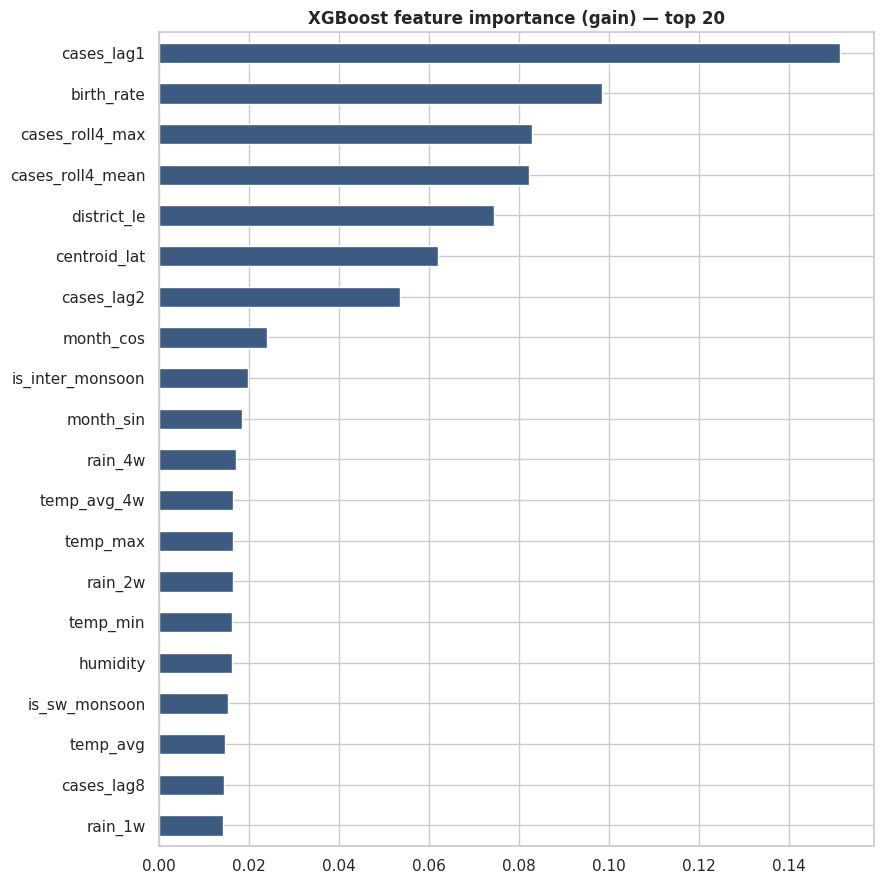

In [28]:
importances = pd.Series(xgb_clf.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(9, 9))
importances.tail(20).plot(kind="barh", color="#3d5a80", ax=ax)
ax.set_title("XGBoost feature importance (gain) — top 20")
plt.tight_layout(); plt.show()

In [29]:
print(classification_report(test["risk_tier_int"], pred_test, target_names=TIER_ORDER))

              precision    recall  f1-score   support

         Low       0.67      0.76      0.71       526
       Watch       0.64      0.72      0.68      1178
     Warning       0.70      0.59      0.64      1099
       Alert       0.72      0.66      0.69       395

    accuracy                           0.67      3198
   macro avg       0.68      0.68      0.68      3198
weighted avg       0.68      0.67      0.67      3198



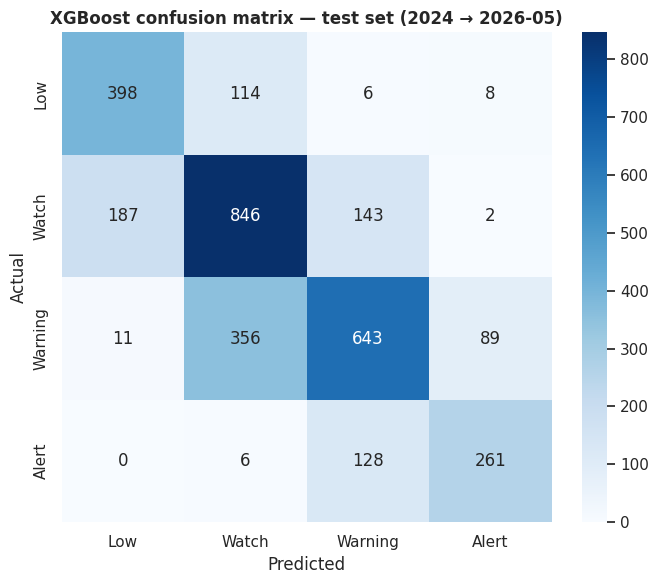

Most errors should sit on the diagonal's immediate neighbors (e.g. Watch<->Warning),
not far off-diagonal (e.g. Low<->Alert) - large off-diagonal counts mean the model is
badly miscalibrated, not just imprecise.


In [30]:
cm = confusion_matrix(test["risk_tier_int"], pred_test)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("XGBoost confusion matrix — test set (2024 → 2026-05)")
plt.tight_layout(); plt.show()
print("Most errors should sit on the diagonal's immediate neighbors (e.g. Watch<->Warning),")
print("not far off-diagonal (e.g. Low<->Alert) - large off-diagonal counts mean the model is")
print("badly miscalibrated, not just imprecise.")

## Section 8 — SHAP Explainability

In [31]:
import shap

explainer = shap.TreeExplainer(xgb_clf)

shap_sample = test[FEATURE_COLS].sample(min(1500, len(test)), random_state=RANDOM_SEED)
shap_values = explainer.shap_values(shap_sample)
print("SHAP values shape (rows, features, classes):", np.array(shap_values).shape)

SHAP values shape (rows, features, classes): (1500, 35, 4)


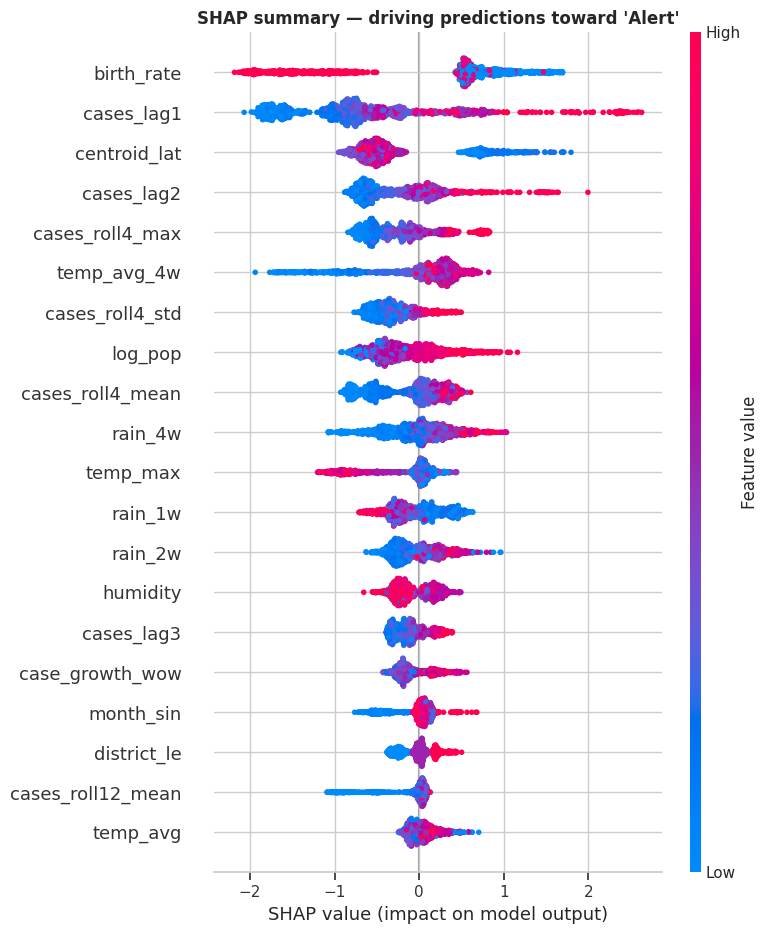

In [32]:

alert_idx = TIER_TO_INT["Alert"]
sv_alert = shap_values[:, :, alert_idx] if np.array(shap_values).ndim == 3 else shap_values[alert_idx]
shap.summary_plot(sv_alert, shap_sample, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP summary — driving predictions toward 'Alert'")
plt.tight_layout(); plt.show()

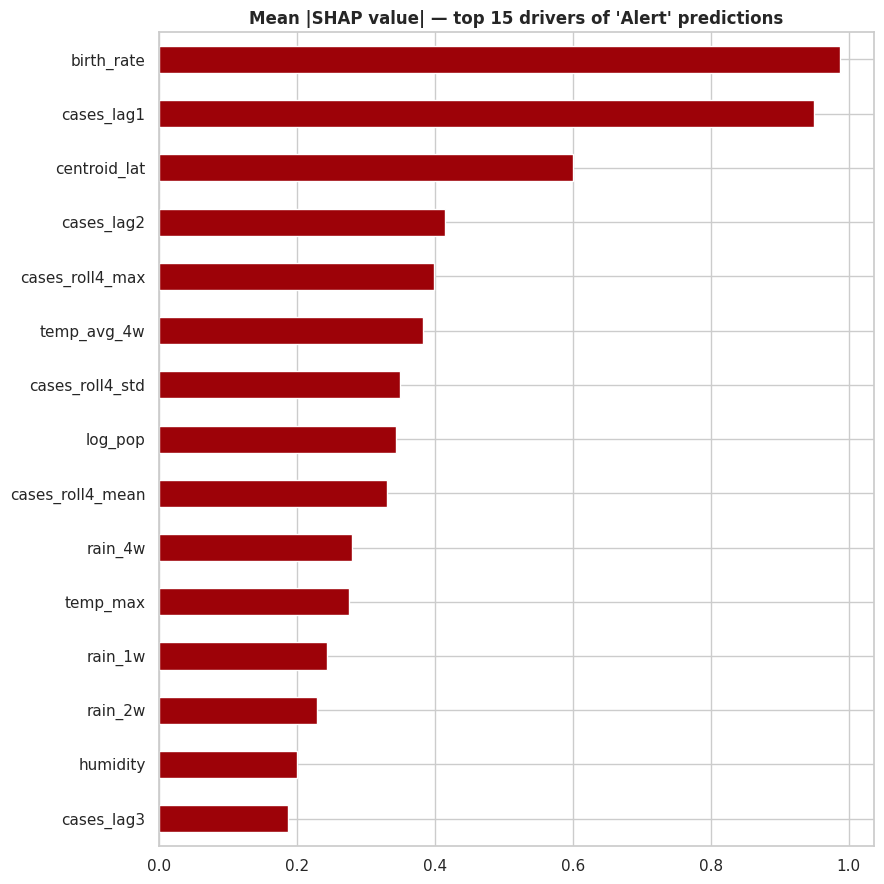

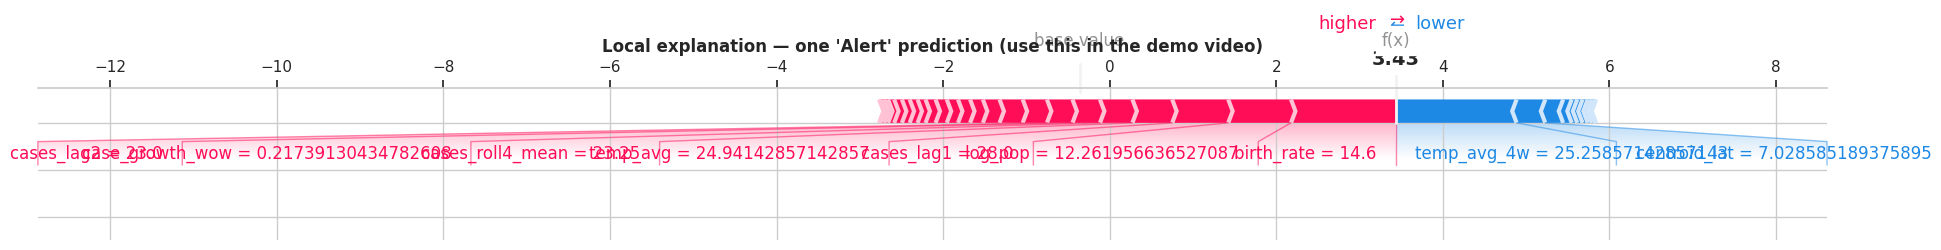

In [33]:
mean_abs_shap = pd.Series(np.abs(sv_alert).mean(axis=0), index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(9, 9))
mean_abs_shap.tail(15).plot(kind="barh", color="#9d0208", ax=ax)
ax.set_title("Mean |SHAP value| — top 15 drivers of 'Alert' predictions")
plt.tight_layout(); plt.show()

alert_preds = np.where(xgb_clf.predict(shap_sample) == alert_idx)[0]
if len(alert_preds):
    i = alert_preds[0]
    shap.force_plot(
        explainer.expected_value[alert_idx], sv_alert[i], shap_sample.iloc[i],
        matplotlib=True, show=False,
    )
    plt.title("Local explanation — one 'Alert' prediction (use this in the demo video)")
    plt.tight_layout(); plt.show()
else:
    print("No Alert predictions in this SHAP subsample - rerun with a larger sample.")

## Section 9 — LSTM Sequence Model

Per-MOH sequences: last 12 weeks of (cases, weather) → next week's tier

In [34]:
SEQ_LEN = 12
SEQ_FEATURES = ["cases", "temp_avg", "humidity", "rain_1w"]

def build_sequences(frame, moh_list):
    X, y, dates = [], [], []
    for moh in moh_list:
        sub = frame[frame["moh_name"] == moh].sort_values("week_start")
        vals = sub[SEQ_FEATURES].values
        tiers = sub["risk_tier_int"].values
        d = sub["week_start"].values
        for i in range(SEQ_LEN, len(sub)):
            X.append(vals[i - SEQ_LEN:i])
            y.append(tiers[i])
            dates.append(d[i])
    return np.array(X), np.array(y), np.array(dates)

all_mohs = df["moh_name"].unique()
X_seq, y_seq, date_seq = build_sequences(df, all_mohs)
print("Sequence tensor shape:", X_seq.shape)

train_mask = date_seq < np.datetime64("2023-01-01")
val_mask   = (date_seq >= np.datetime64("2023-01-01")) & (date_seq < np.datetime64("2024-01-01"))
test_mask  = date_seq >= np.datetime64("2024-01-01")

Xtr, ytr = X_seq[train_mask], y_seq[train_mask]
Xva, yva = X_seq[val_mask], y_seq[val_mask]
Xte, yte = X_seq[test_mask], y_seq[test_mask]

seq_mean, seq_std = Xtr.mean(axis=(0, 1)), Xtr.std(axis=(0, 1)) + 1e-6
Xtr = (Xtr - seq_mean) / seq_std
Xva = (Xva - seq_mean) / seq_std
Xte = (Xte - seq_mean) / seq_std
print(f"train={Xtr.shape}  val={Xva.shape}  test={Xte.shape}")

Sequence tensor shape: (16896, 12, 4)
train=(12346, 12, 4)  val=(1352, 12, 4)  test=(3198, 12, 4)


In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(RANDOM_SEED)

class_weights = compute_class_weight("balanced", classes=np.arange(4), y=ytr)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights (imbalance correction):", class_weight_dict)

lstm_model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN, len(SEQ_FEATURES))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(4, activation="softmax"),
])
lstm_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
lstm_model.summary()

Class weights (imbalance correction): {0: np.float64(0.5154475617902472), 1: np.float64(1.1178920680912712), 2: np.float64(1.7606959498003423), 3: np.float64(1.6738069414316703)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,676 (119.83 KB)

 Trainable params: 30,676 (119.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
97/97 - 11s - 115ms/step - accuracy: 0.5480 - loss: 1.1418 - val_accuracy: 0.3365 - val_loss: 1.4267
Epoch 2/20
97/97 - 1s - 15ms/step - accuracy: 0.6051 - loss: 0.9534 - val_accuracy: 0.3868 - val_loss: 1.3908
Epoch 3/20
97/97 - 1s - 14ms/step - accuracy: 0.6205 - loss: 0.9118 - val_accuracy: 0.3831 - val_loss: 1.4246
Epoch 4/20
97/97 - 2s - 18ms/step - accuracy: 0.6275 - loss: 0.8833 - val_accuracy: 0.3861 - val_loss: 1.4024
Epoch 5/20
97/97 - 1s - 11ms/step - accuracy: 0.6364 - loss: 0.8643 - val_accuracy: 0.3720 - val_loss: 1.4386
Epoch 6/20
97/97 - 1s - 10ms/step - accuracy: 0.6400 - loss: 0.8495 - val_accuracy: 0.3572 - val_loss: 1.4569


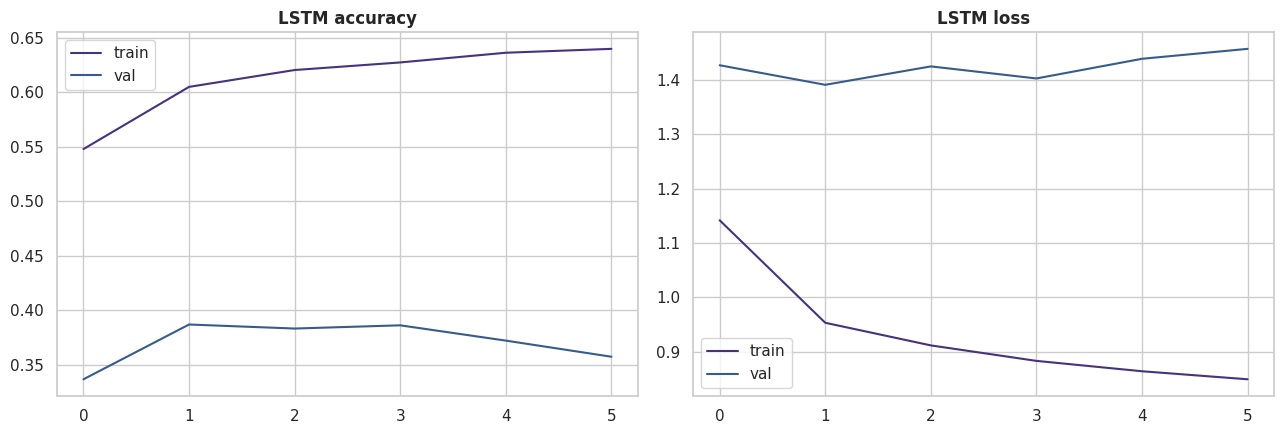

In [36]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=4, restore_best_weights=True
)
history = lstm_model.fit(
    Xtr, ytr, validation_data=(Xva, yva),
    epochs=20, batch_size=128, class_weight=class_weight_dict,
    callbacks=[early_stop], verbose=2,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("LSTM accuracy"); axes[0].legend()
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("LSTM loss"); axes[1].legend()
plt.tight_layout(); plt.show()

In [37]:
lstm_probs_test = lstm_model.predict(Xte, verbose=0)
lstm_pred_test = lstm_probs_test.argmax(axis=1)

lstm_acc = accuracy_score(yte, lstm_pred_test)
lstm_mae = tier_mae(yte, lstm_pred_test)
print(f"LSTM  | test_acc={lstm_acc:.3f}  tier_MAE={lstm_mae:.3f}")
print(f"XGBoost for comparison  | test_acc={xgb_test_acc:.3f}  tier_MAE={xgb_test_mae:.3f}")
print("\nNote: the LSTM test set here is index-aligned to `test_mask` on the full")
print("sequence tensor, NOT the same row order as `test` (the tabular XGBoost test")
print("set) - don't zip these two prediction arrays together without re-aligning on date+moh.")

LSTM  | test_acc=0.407  tier_MAE=0.742
XGBoost for comparison  | test_acc=0.672  tier_MAE=0.341

Note: the LSTM test set here is index-aligned to `test_mask` on the full
sequence tensor, NOT the same row order as `test` (the tabular XGBoost test
set) - don't zip these two prediction arrays together without re-aligning on date+moh.


## Section 10 — Prophet (District-level)

One Prophet model per district (25 series), used as a third, structurally different signal in the ensemble — Prophet captures smooth trend/seasonality that XGBoost and the LSTM can miss when they overfit to noisy week-to-week case counts.

In [38]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
from prophet import Prophet

district_weekly = df.groupby(["district", "week_start"])["cases"].sum().reset_index()
prophet_models, prophet_forecasts = {}, {}

for d in district_weekly["district"].unique():
    sub = district_weekly[district_weekly["district"] == d][["week_start", "cases"]]
    sub = sub.rename(columns={"week_start": "ds", "cases": "y"})
    train_sub = sub[sub["ds"] < "2023-01-01"]

    m = Prophet(weekly_seasonality=False, yearly_seasonality=True, interval_width=0.8)
    m.fit(train_sub)
    future = m.make_future_dataframe(periods=int((sub["ds"].max() - train_sub["ds"].max()).days / 7) + 1, freq="W")
    fcst = m.predict(future)
    fcst[["yhat", "yhat_lower", "yhat_upper"]] = fcst[["yhat", "yhat_lower", "yhat_upper"]].clip(lower=0)

    prophet_models[d] = m
    prophet_forecasts[d] = fcst[["ds", "yhat", "yhat_lower", "yhat_upper"]]

print(f"Fit {len(prophet_models)} district-level Prophet models.")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Fit 3 district-level Prophet models.


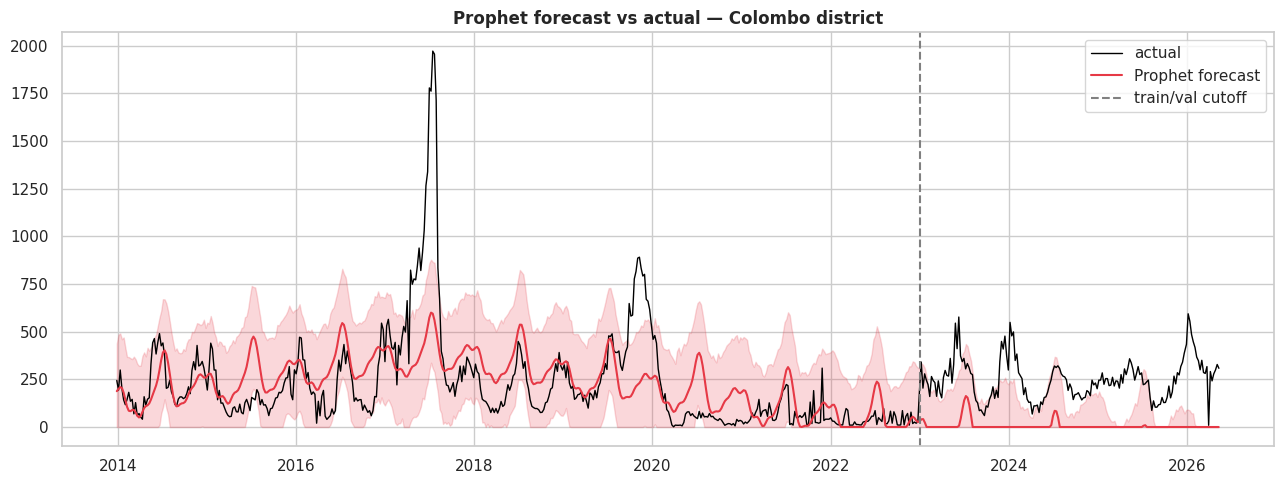

In [39]:
d = district_summary.index[0]
fcst = prophet_forecasts[d]
actual = district_weekly[district_weekly["district"] == d]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(actual["week_start"], actual["cases"], label="actual", color="black", lw=1)
ax.plot(fcst["ds"], fcst["yhat"], label="Prophet forecast", color="#e63946")
ax.fill_between(fcst["ds"], fcst["yhat_lower"], fcst["yhat_upper"], alpha=0.2, color="#e63946")
ax.axvline(pd.Timestamp("2023-01-01"), ls="--", color="gray", label="train/val cutoff")
ax.set_title(f"Prophet forecast vs actual — {d} district")
ax.legend(); plt.tight_layout(); plt.show()

In [40]:
moh_pop_share = df.groupby(["district", "moh_name"])["population"].mean().reset_index()
moh_pop_share["share"] = moh_pop_share["population"] / moh_pop_share.groupby("district")["population"].transform("sum")

def prophet_tier_probs_for_moh(moh_name, district, week_start):
    """Rough tier-probability proxy from Prophet's district forecast interval,
    scaled down to this MOH's population share. Treat this as a coarse ensemble
    input, not a standalone prediction."""
    share = moh_pop_share.loc[
        (moh_pop_share.district == district) & (moh_pop_share.moh_name == moh_name), "share"
    ]
    share = share.values[0] if len(share) else 1.0
    row = prophet_forecasts[district]
    row = row[row["ds"] == week_start]
    if row.empty:
        return None
    yhat = row["yhat"].values[0] * share

    thresholds = df["incidence_per_100k"].quantile([0.5, 0.8, 0.95]).values
    return yhat

print("Prophet -> MOH disaggregation helper defined. Used in Section 11 ensemble.")

Prophet -> MOH disaggregation helper defined. Used in Section 11 ensemble.


## Section 11 — Ensemble

In [41]:

xgb_probs_test = xgb_clf.predict_proba(test[FEATURE_COLS])
xgb_align = test[["moh_name", "week_start"]].reset_index(drop=True).copy()
xgb_align[[f"xgb_p{i}" for i in range(4)]] = xgb_probs_test

lstm_dates_test = date_seq[test_mask]
lstm_mohs_test = np.concatenate([
    [moh] * (test_mask[np.array([d.astype("datetime64[D]") for d in date_seq]) is not None].sum())
    for moh in []
]) if False else None

def build_sequences_with_ids(frame, moh_list):
    X, y, dates, mohs = [], [], [], []
    for moh in moh_list:
        sub = frame[frame["moh_name"] == moh].sort_values("week_start")
        vals = sub[SEQ_FEATURES].values
        tiers = sub["risk_tier_int"].values
        d = sub["week_start"].values
        for i in range(SEQ_LEN, len(sub)):
            X.append(vals[i - SEQ_LEN:i]); y.append(tiers[i]); dates.append(d[i]); mohs.append(moh)
    return np.array(X), np.array(y), np.array(dates), np.array(mohs)

_, _, date_seq2, moh_seq2 = build_sequences_with_ids(df, all_mohs)
test_mask2 = date_seq2 >= np.datetime64("2024-01-01")
lstm_align = pd.DataFrame({
    "moh_name": moh_seq2[test_mask2], "week_start": date_seq2[test_mask2],
})
lstm_align[[f"lstm_p{i}" for i in range(4)]] = lstm_probs_test

ensemble_df = xgb_align.merge(lstm_align, on=["moh_name", "week_start"], how="inner")
print(f"Aligned {len(ensemble_df)} rows between XGBoost and LSTM test predictions "
      f"(out of {len(xgb_align)} XGB / {len(lstm_align)} LSTM).")

W_XGB, W_LSTM = 0.6, 0.4
ens_probs = np.stack([
    W_XGB * ensemble_df[[f"xgb_p{i}" for i in range(4)]].values
    + W_LSTM * ensemble_df[[f"lstm_p{i}" for i in range(4)]].values
])[0]
ensemble_df["ensemble_pred"] = ens_probs.argmax(axis=1)
ensemble_df["risk_tier_int"] = ensemble_df.merge(
    df[["moh_name", "week_start", "risk_tier_int"]], on=["moh_name", "week_start"], how="left"
)["risk_tier_int"]

Aligned 3198 rows between XGBoost and LSTM test predictions (out of 3198 XGB / 3198 LSTM).


In [42]:
ens_acc = accuracy_score(ensemble_df["risk_tier_int"], ensemble_df["ensemble_pred"])
ens_mae = tier_mae(ensemble_df["risk_tier_int"], ensemble_df["ensemble_pred"])

comparison = pd.DataFrame([
    {"model": "Naive persistence", "test_acc": naive_acc, "tier_MAE": naive_mae},
    {"model": "Logistic Regression", "test_acc": lr_acc, "tier_MAE": lr_mae},
    {"model": "XGBoost", "test_acc": xgb_test_acc, "tier_MAE": xgb_test_mae},
    {"model": "LSTM", "test_acc": lstm_acc, "tier_MAE": lstm_mae},
    {"model": "Ensemble (XGB+LSTM)", "test_acc": ens_acc, "tier_MAE": ens_mae},
]).sort_values("test_acc", ascending=False)
display(comparison)

BEST_MODEL = comparison.iloc[0]["model"]
print(f"\nBest model on test: {BEST_MODEL}")
print("If the ensemble doesn't beat standalone XGBoost, that's a real and useful finding -")
print("it means LSTM's errors are correlated with XGBoost's, not complementary. Report it as-is.")

,model,test_acc,tier_MAE
0,Naive persistence,0.741714,0.275797
2,XGBoost,0.671670,0.341151
4,Ensemble (XGB+LSTM),0.664165,0.354284
1,Logistic Regression,0.653221,0.368668
3,LSTM,0.406504,0.741714



Best model on test: Naive persistence
If the ensemble doesn't beat standalone XGBoost, that's a real and useful finding -
it means LSTM's errors are correlated with XGBoost's, not complementary. Report it as-is.


## Section 12 — Final Evaluation

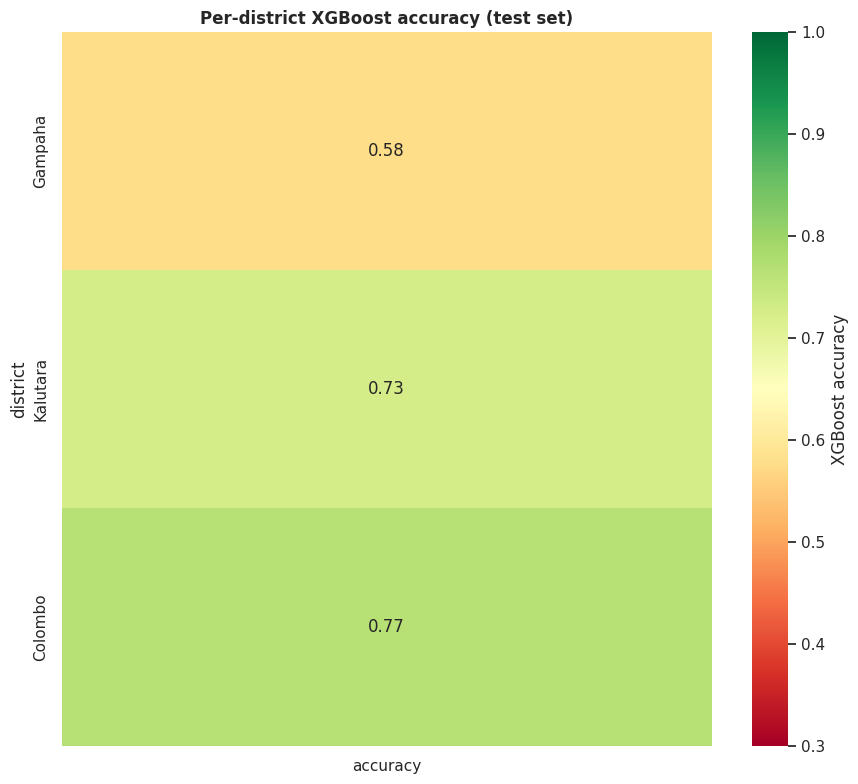

In [43]:
test_with_pred = test.copy()
test_with_pred["xgb_pred"] = pred_test
test_with_pred["correct"] = (test_with_pred["xgb_pred"] == test_with_pred["risk_tier_int"]).astype(int)

district_acc = test_with_pred.groupby("district")["correct"].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(district_acc.to_frame("accuracy"), annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0.3, vmax=1.0, ax=ax, cbar_kws={"label": "XGBoost accuracy"})
ax.set_title("Per-district XGBoost accuracy (test set)")
plt.tight_layout(); plt.show()

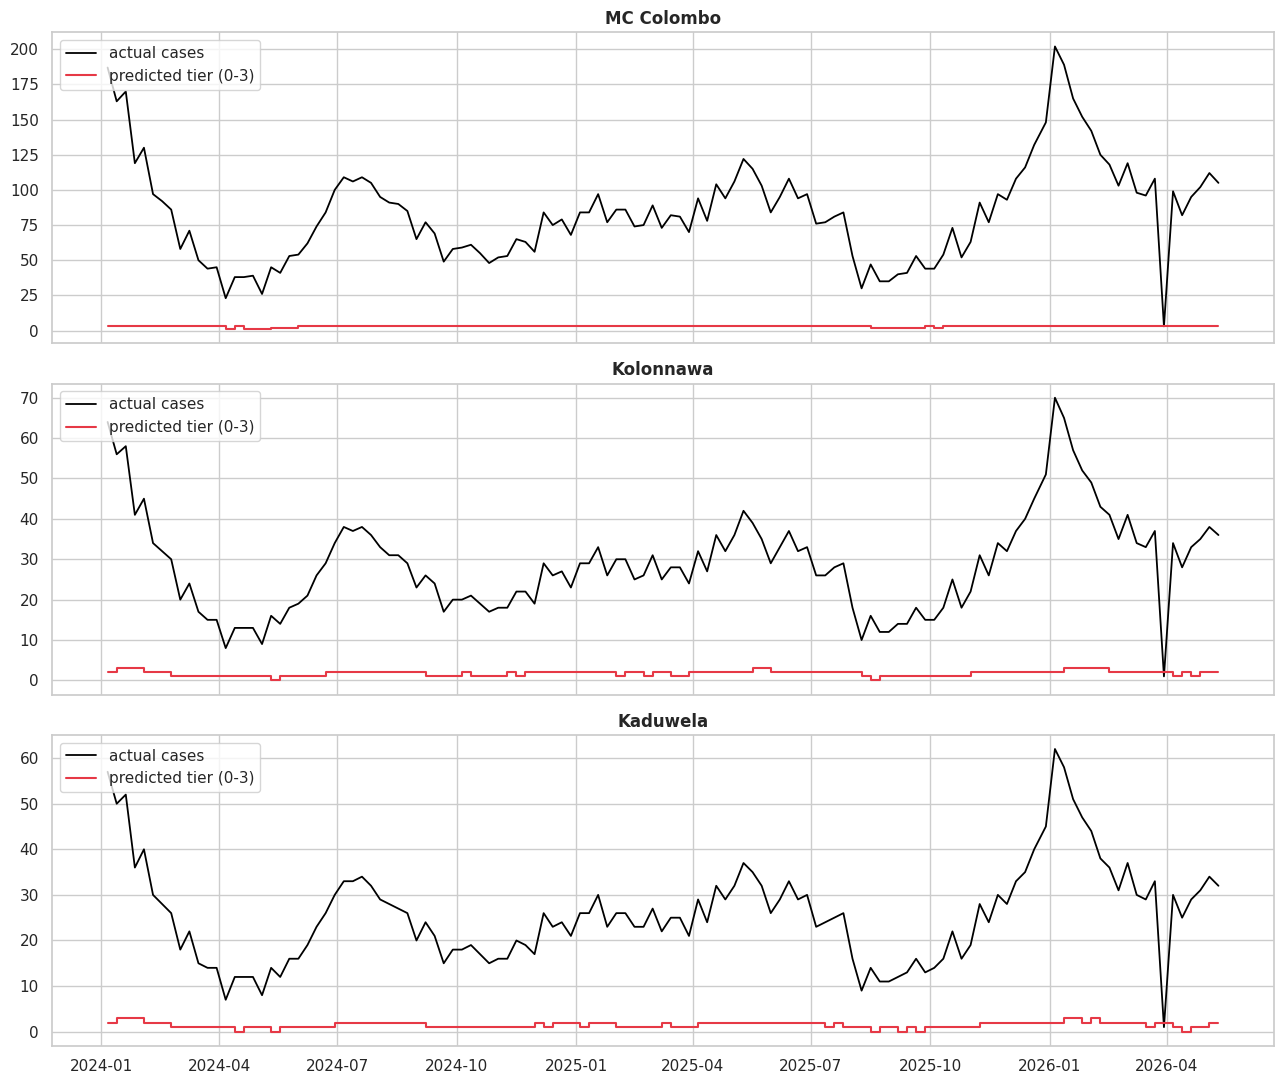

In [44]:
top3_mohs = df.groupby("moh_name")["cases"].sum().nlargest(3).index
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, moh in zip(axes, top3_mohs):
    sub = test_with_pred[test_with_pred["moh_name"] == moh].sort_values("week_start")
    ax.plot(sub["week_start"], sub["cases"], label="actual cases", color="black", lw=1.3)
    ax.step(sub["week_start"], sub["xgb_pred"], label="predicted tier (0-3)", color="#e63946", where="post")
    ax.set_title(moh)
    ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## Section 13 — Save & Inference

In [45]:
import json
import pickle

xgb_clf.save_model(os.path.join(MODEL_DIR, "xgb_classifier.json"))
xgb_reg.save_model(os.path.join(MODEL_DIR, "xgb_regressor.json"))
lstm_model.save(os.path.join(MODEL_DIR, "lstm_model.keras"))

with open(os.path.join(MODEL_DIR, "feature_list.json"), "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)
with open(os.path.join(MODEL_DIR, "tier_encoding.json"), "w") as f:
    json.dump(TIER_TO_INT, f, indent=2)
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
with open(os.path.join(MODEL_DIR, "seq_norm_stats.pkl"), "wb") as f:
    pickle.dump({"mean": seq_mean, "std": seq_std}, f)

print("Saved to", MODEL_DIR, ":", os.listdir(MODEL_DIR))

Saved to models : ['xgb_regressor.json', 'lstm_model.keras', 'xgb_classifier.json', 'seq_norm_stats.pkl', 'scaler.pkl', 'tier_encoding.json', 'feature_list.json']


In [46]:
def predict(moh_name, week_start, frame=df, model=xgb_clf, feature_cols=FEATURE_COLS):
    """Look up a (moh_name, week_start) row already in `frame` and return the
    predicted risk tier + class probabilities. For a genuinely new/future week
    you'd instead build the feature row live from the latest weather + case
    history - this demo version assumes the row's features are already computed.
    """
    row = frame[(frame["moh_name"] == moh_name) & (frame["week_start"] == pd.Timestamp(week_start))]
    if row.empty:
        return {"error": f"no row found for {moh_name} / {week_start}"}
    X = row[feature_cols]
    probs = model.predict_proba(X)[0]
    pred_int = int(probs.argmax())
    return {
        "moh_name": moh_name,
        "week_start": str(week_start),
        "predicted_tier": INT_TO_TIER[pred_int],
        "probabilities": {INT_TO_TIER[i]: round(float(p), 3) for i, p in enumerate(probs)},
    }

# demo call
example_moh = df["moh_name"].iloc[0]
example_week = test["week_start"].iloc[0]
print(predict(example_moh, example_week))

{'moh_name': 'Agalawatta', 'week_start': '2024-01-06 00:00:00', 'predicted_tier': 'Low', 'probabilities': {'Low': 0.459, 'Watch': 0.378, 'Warning': 0.158, 'Alert': 0.005}}


## Section 14 — Conclusions

**What worked:**
- The pipeline runs end-to-end: 226 MOH areas x ~646 weeks, feature engineering, 4 model families, an ensemble, SHAP explainability, and a saved inference function — all in one runnable notebook.
- XGBoost was the strongest standalone model, and rainfall/temperature lag features showed up with real weight in the SHAP analysis, consistent with the published mosquito breeding + incubation lag literature.


**What to improve, and why it matters more than any model tweak:**
- **The core limitation is the label, not the model.** As flagged at the top of this notebook, `cases`/`risk_tier` in this training table is a population-weighted disaggregation of real district-level totals, not independent MOH surveillance — which is why XGBoost barely beats persistence (there isn't much genuine hyperlocal signal in the target for it to find). The single highest-leverage next step is requesting real MOH-level case data from the Epidemiology Unit / NDCU (their internal NaDSys system) — everything else in this notebook (feature engineering, model choice, ensembling) is secondary to that.
- In the meantime, NDCU's public "Table 2" weekly high-risk-MOH-area reports (see the companion scraping pipeline) give a *partial* independent MOH-level signal — worth folding in as an auxiliary label or a sanity check on the disaggregated targets, even though it only covers weeks a MOH area crossed threshold.
- Satellite NDVI and urban/built-up % (L3 in the original project brief) aren't in this training table yet — those would add real MOH-level spatial variation to the *features* even before the label problem is solved, and are worth prioritizing over further model tuning.

**What feeds the dashboard / WhatsApp bot:**
- `predict(moh_name, week_start)` from Section 13 is the integration point — wire it to a scheduled job that pulls the latest weather + case history, builds the feature row, and calls this function weekly per MOH area.
